<a href="https://www.kaggle.com/code/sonawanelalitsunil/user-vs-bot-classification-ml-96-60?scriptVersionId=233631531" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/users-vs-bots-classification/bots_vs_users.csv


## Title: User vs Bot Classification

### Description: Develop a model to distinguish between human users and bots based on behavioral patterns, clickstream data, and interaction features.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/users-vs-bots-classification/bots_vs_users.csv')

In [3]:
df.head()

,has_domain,has_birth_date,has_photo,can_post_on_wall,can_send_message,has_website,gender,has_short_name,has_first_name,has_last_name,...,ads_ratio,avg_views,posting_frequency_days,phone_numbers_ratio,avg_text_uniqueness,city,has_occupation,occupation_type_university,occupation_type_work,has_personal_data
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
4,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown


In [4]:
df.tail()

,has_domain,has_birth_date,has_photo,can_post_on_wall,can_send_message,has_website,gender,has_short_name,has_first_name,has_last_name,...,ads_ratio,avg_views,posting_frequency_days,phone_numbers_ratio,avg_text_uniqueness,city,has_occupation,occupation_type_university,occupation_type_work,has_personal_data
5869,1.0,1.0,1.0,0.0,0.0,Unknown,2.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Saint Petersburg,1.0,0.0,1.0,Unknown
5870,1.0,Unknown,1.0,0.0,0.0,Unknown,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Saint Petersburg,1.0,1.0,0.0,Unknown
5871,1.0,1.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Saint Petersburg,1.0,1.0,0.0,Unknown
5872,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Moscow,1.0,0.0,1.0,Unknown
5873,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,431.3,17.79,0.0,0.61,Saint Petersburg,1.0,0.0,1.0,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5874 entries, 0 to 5873
Data columns (total 60 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   has_domain                  5874 non-null   object 
 1   has_birth_date              5874 non-null   object 
 2   has_photo                   5874 non-null   object 
 3   can_post_on_wall            5874 non-null   object 
 4   can_send_message            5874 non-null   object 
 5   has_website                 5874 non-null   object 
 6   gender                      5874 non-null   object 
 7   has_short_name              5874 non-null   object 
 8   has_first_name              5874 non-null   object 
 9   has_last_name               5874 non-null   object 
 10  access_to_closed_profile    5874 non-null   object 
 11  is_profile_closed           5874 non-null   object 
 12  target                      5874 non-null   int64  
 13  has_nickname                5874 

In [6]:
df.describe()

,target,posts_count,avg_likes,links_ratio,hashtags_ratio,avg_keywords,avg_text_length,attachments_ratio,avg_comments,reposts_ratio,ads_ratio,avg_views,posting_frequency_days,phone_numbers_ratio,avg_text_uniqueness
count,5874.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000,1391.000000
mean,0.500000,18.629044,19.552487,0.156463,0.143918,7.730661,544.752035,0.895945,0.610812,0.433638,0.002667,623.834788,66.330065,0.000568,0.668009
std,0.500043,4.231994,41.954881,0.202730,0.187085,11.278711,746.728130,0.170084,2.461709,0.397830,0.033136,1617.635460,154.970296,0.009545,0.229815
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.000000,0.400000,0.000000,0.000000,1.100000,86.600000,0.850000,0.000000,0.050000,0.000000,9.125000,1.980000,0.000000,0.580000
50%,0.500000,20.000000,7.600000,0.100000,0.050000,3.400000,267.800000,0.950000,0.000000,0.300000,0.000000,268.950000,30.950000,0.000000,0.710000
75%,1.000000,20.000000,26.075000,0.200000,0.200000,7.850000,616.850000,1.000000,0.200000,0.900000,0.000000,746.050000,89.480000,0.000000,0.830000
max,1.000000,20.000000,894.900000,1.000000,1.000000,61.600000,5841.250000,1.000000,64.050000,1.000000,0.950000,41415.700000,2866.590000,0.300000,1.000000


In [7]:
df.isnull().sum()

has_domain                       0
has_birth_date                   0
has_photo                        0
can_post_on_wall                 0
can_send_message                 0
has_website                      0
gender                           0
has_short_name                   0
has_first_name                   0
has_last_name                    0
access_to_closed_profile         0
is_profile_closed                0
target                           0
has_nickname                     0
has_maiden_name                  0
has_mobile                       0
all_posts_visible                0
audio_available                  0
has_interests                    0
has_books                        0
has_tv                           0
has_quotes                       0
has_about                        0
has_games                        0
has_movies                       0
has_activities                   0
has_music                        0
can_add_as_friend                0
can_invite_to_group 

In [8]:
df.duplicated().sum()

2616

In [9]:
df.shape

(5874, 60)

In [10]:
df.dtypes

has_domain                     object
has_birth_date                 object
has_photo                      object
can_post_on_wall               object
can_send_message               object
has_website                    object
gender                         object
has_short_name                 object
has_first_name                 object
has_last_name                  object
access_to_closed_profile       object
is_profile_closed              object
target                          int64
has_nickname                   object
has_maiden_name                object
has_mobile                     object
all_posts_visible              object
audio_available                object
has_interests                  object
has_books                      object
has_tv                         object
has_quotes                     object
has_about                      object
has_games                      object
has_movies                     object
has_activities                 object
has_music   

In [11]:
df.columns

Index(['has_domain', 'has_birth_date', 'has_photo', 'can_post_on_wall',
       'can_send_message', 'has_website', 'gender', 'has_short_name',
       'has_first_name', 'has_last_name', 'access_to_closed_profile',
       'is_profile_closed', 'target', 'has_nickname', 'has_maiden_name',
       'has_mobile', 'all_posts_visible', 'audio_available', 'has_interests',
       'has_books', 'has_tv', 'has_quotes', 'has_about', 'has_games',
       'has_movies', 'has_activities', 'has_music', 'can_add_as_friend',
       'can_invite_to_group', 'subscribers_count', 'is_blacklisted',
       'has_career', 'has_military_service', 'has_hometown', 'marital_status',
       'has_universities', 'has_schools', 'has_relatives', 'is_verified',
       'is_confirmed', 'has_status', 'posts_count', 'avg_likes', 'links_ratio',
       'hashtags_ratio', 'avg_keywords', 'avg_text_length',
       'attachments_ratio', 'avg_comments', 'reposts_ratio', 'ads_ratio',
       'avg_views', 'posting_frequency_days', 'phone_numbe

## Data visualizations

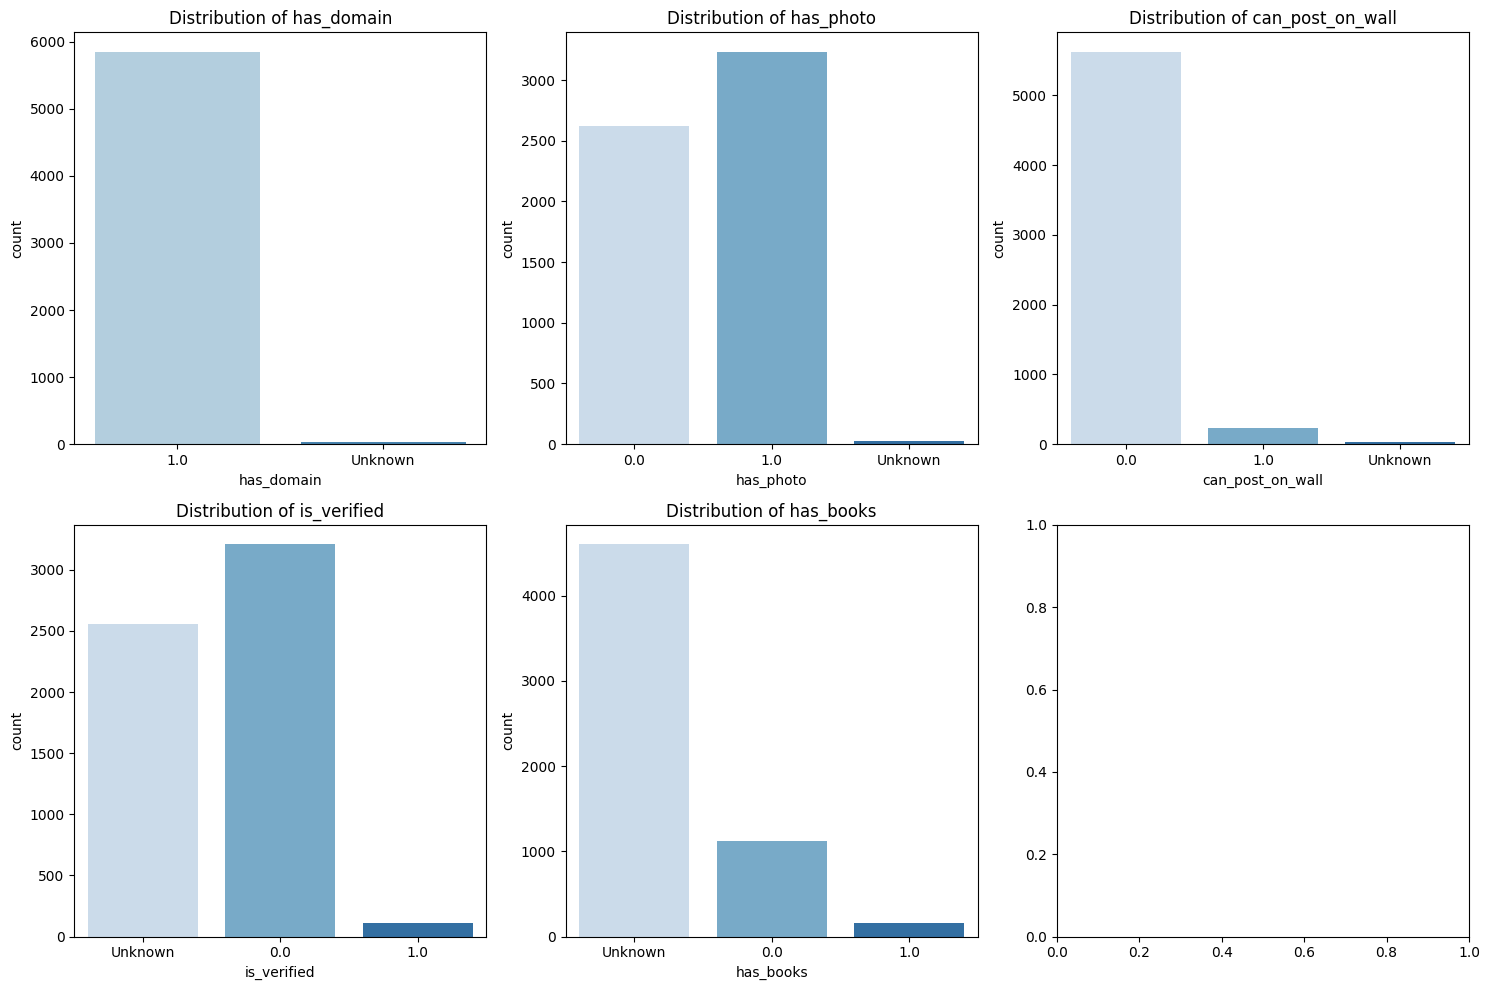

In [12]:
binary_cols = ['has_domain', 'has_photo', 'can_post_on_wall', 'is_verified', 'has_books']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(binary_cols):
    ax = axes[i // 3, i % 3]
    sns.countplot(x=col, data=df, ax=ax, palette="Blues")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

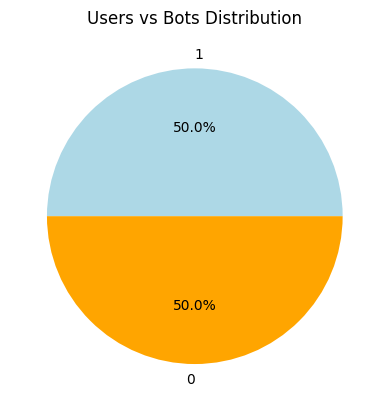

In [13]:
df['target'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'orange'])
plt.title("Users vs Bots Distribution")
plt.ylabel("")
plt.show()


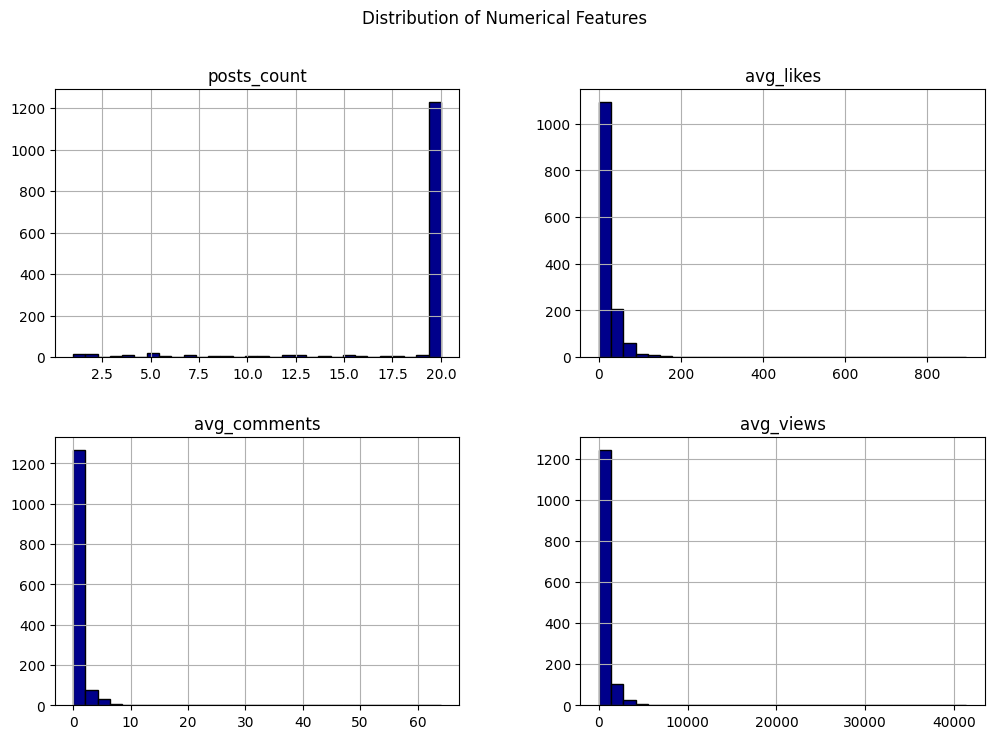

In [14]:
num_cols = ['posts_count', 'avg_likes', 'avg_comments', 'avg_views', 'subscribers_count']
df[num_cols].hist(figsize=(12, 8), bins=30, color='darkblue', edgecolor='black')
plt.suptitle("Distribution of Numerical Features")
plt.show()


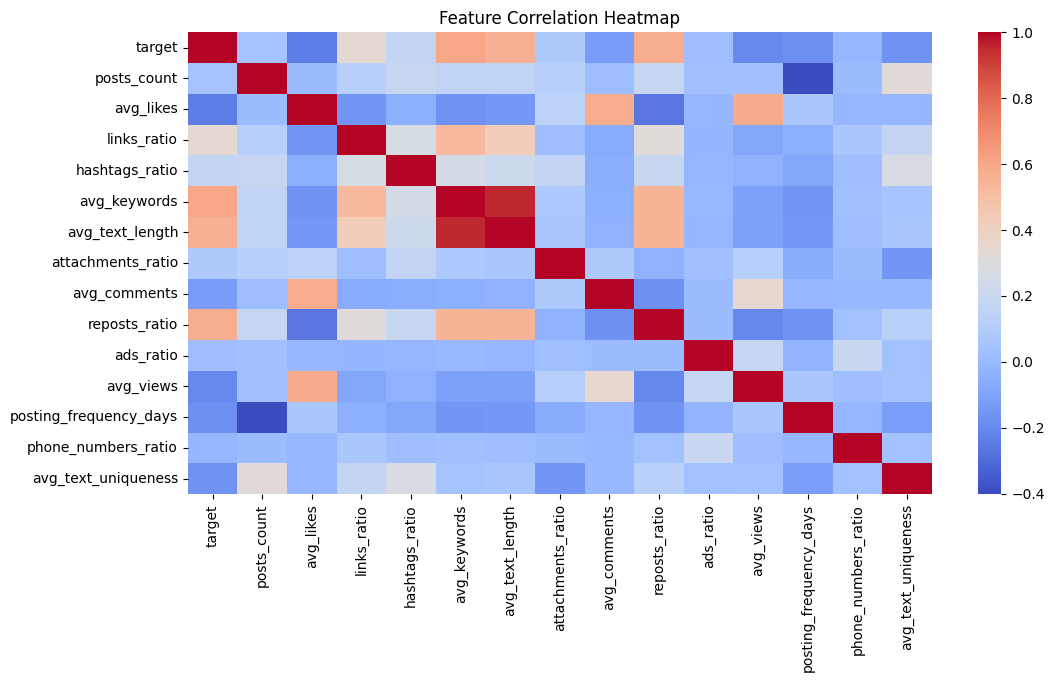

In [15]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

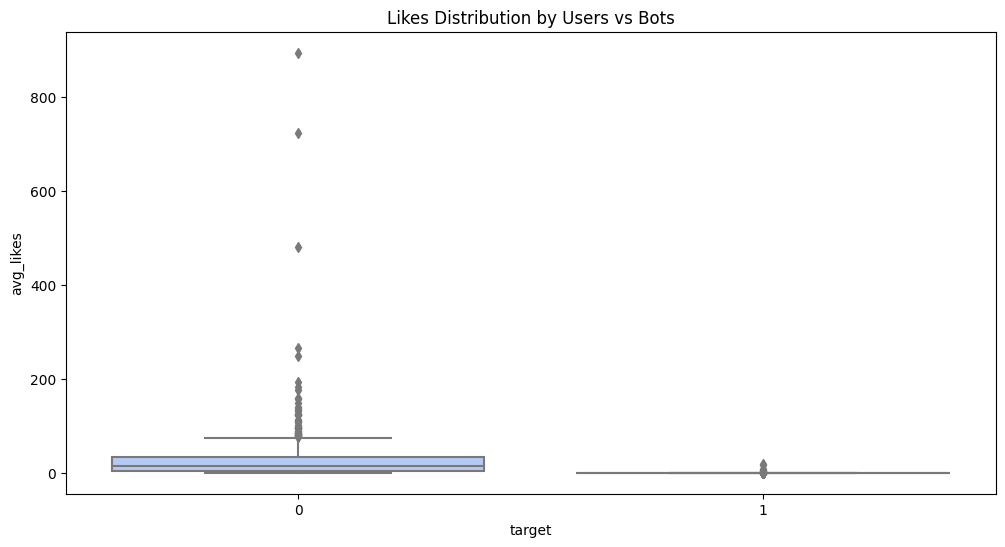

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='target', y='avg_likes', data=df, palette='coolwarm')
plt.title("Likes Distribution by Users vs Bots")
plt.show()


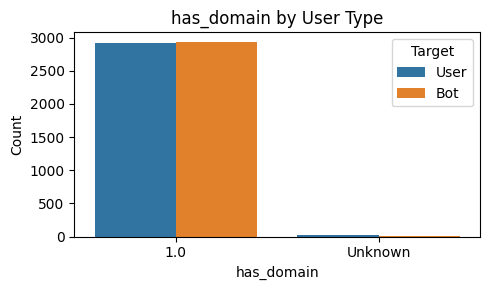

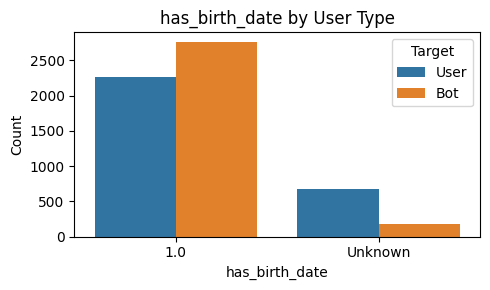

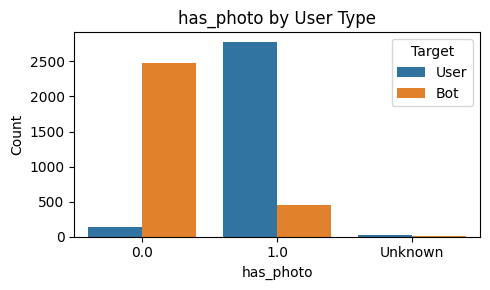

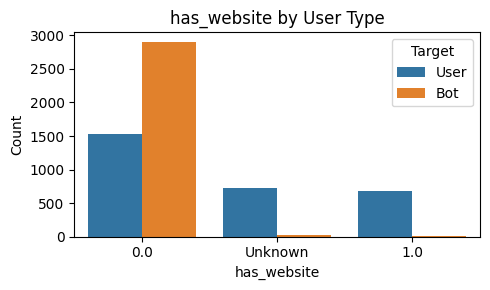

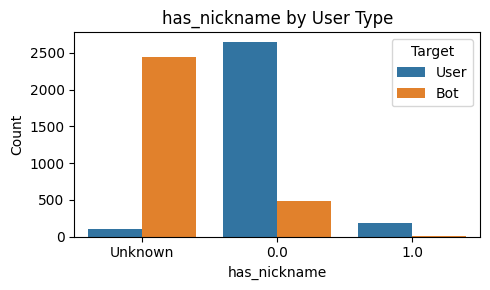

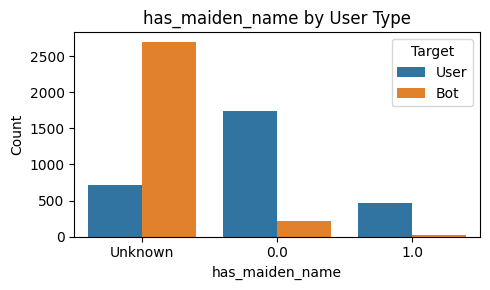

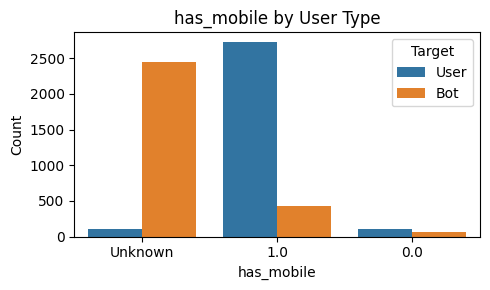

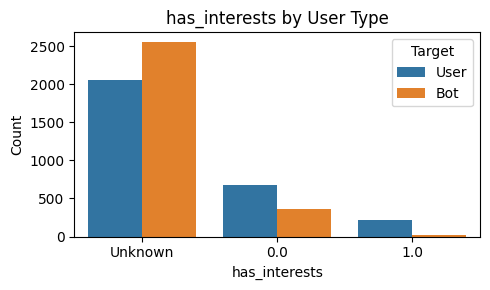

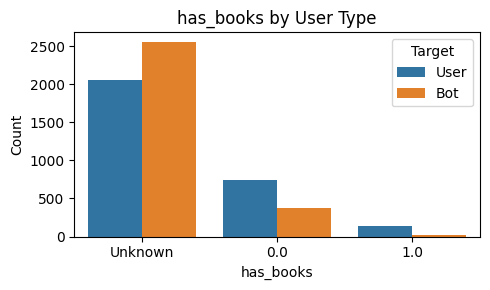

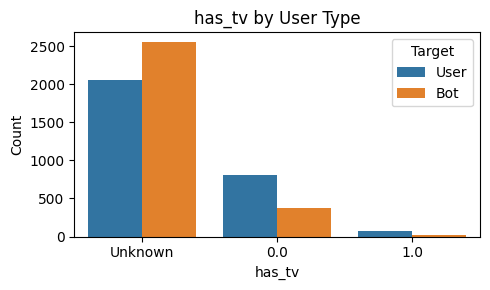

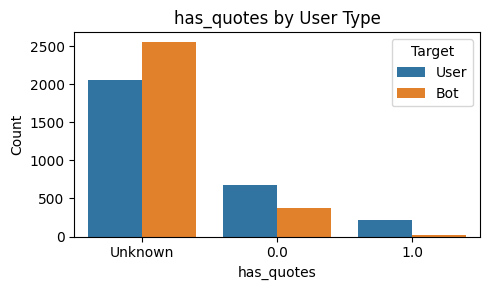

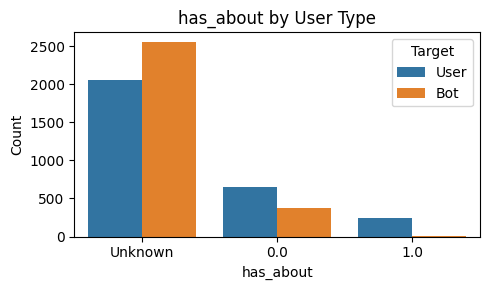

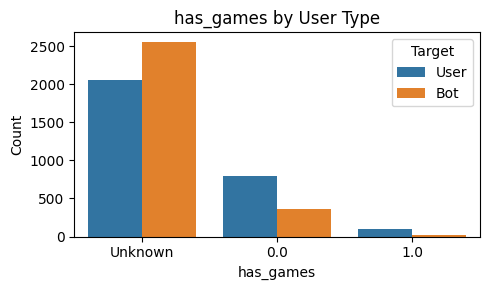

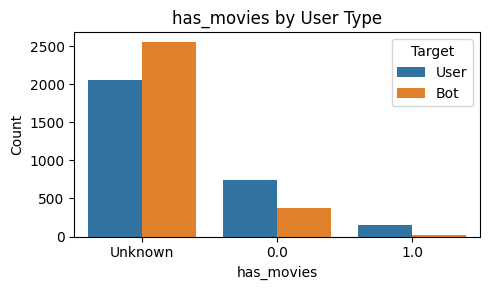

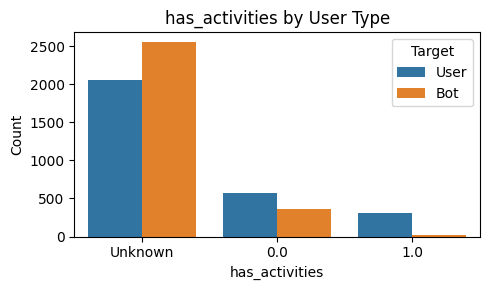

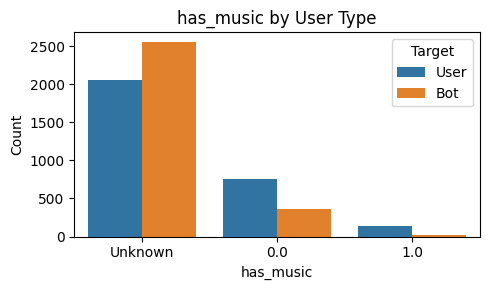

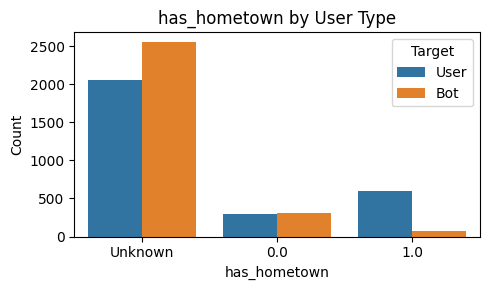

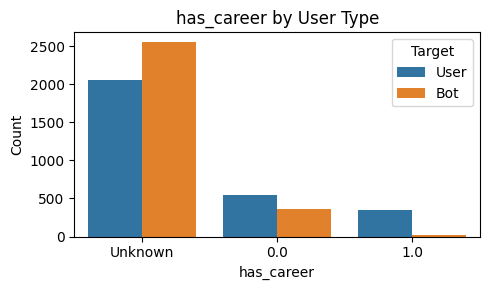

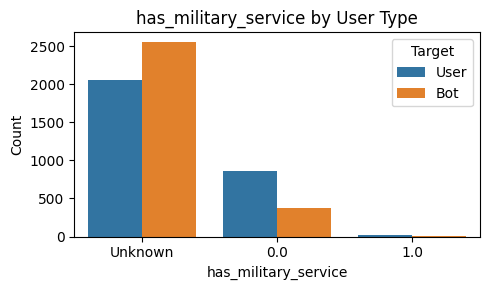

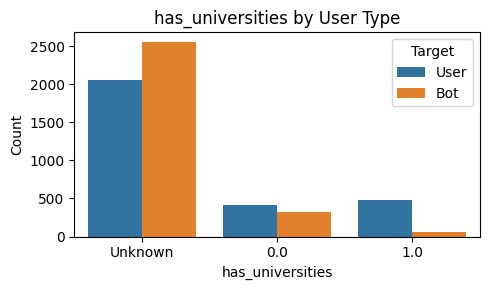

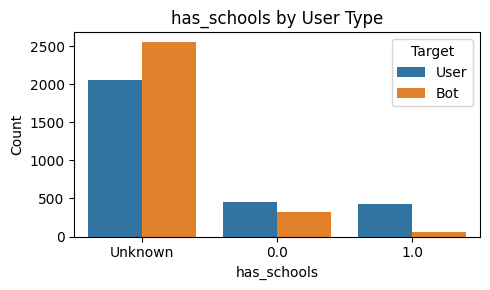

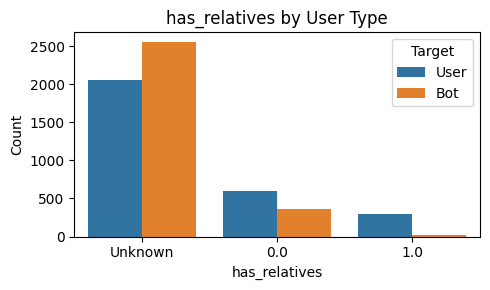

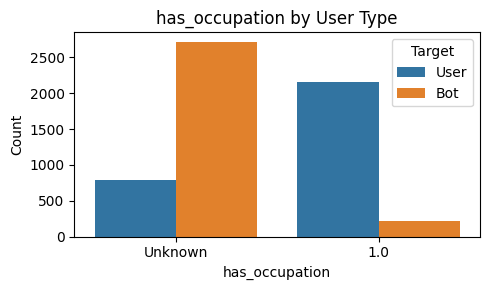

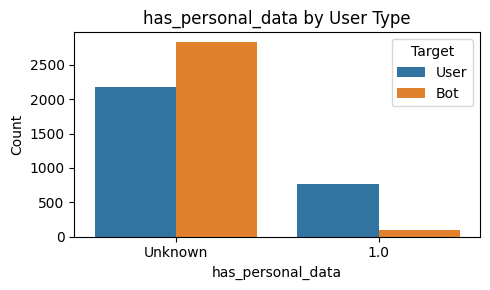

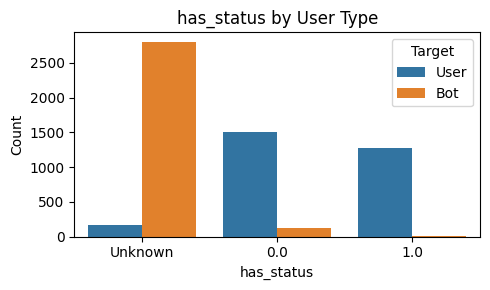

In [17]:
binary_cols = [
    'has_domain', 'has_birth_date', 'has_photo', 'has_website', 'has_nickname',
    'has_maiden_name', 'has_mobile', 'has_interests', 'has_books', 'has_tv',
    'has_quotes', 'has_about', 'has_games', 'has_movies', 'has_activities',
    'has_music', 'has_hometown', 'has_career', 'has_military_service',
    'has_universities', 'has_schools', 'has_relatives', 'has_occupation',
    'has_personal_data', 'has_status'
]

for col in binary_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(data=df, x=col, hue='target')
    plt.title(f"{col} by User Type")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title='Target', labels=['User', 'Bot'])
    plt.tight_layout()
    plt.show()


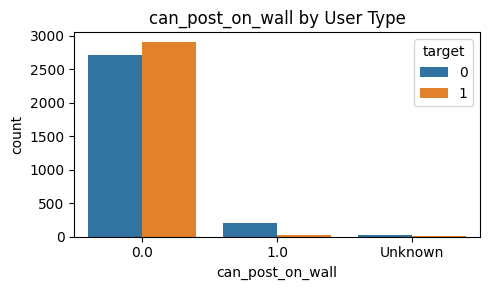

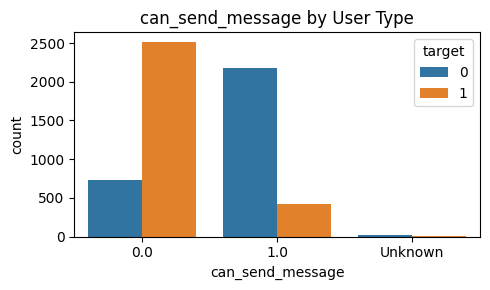

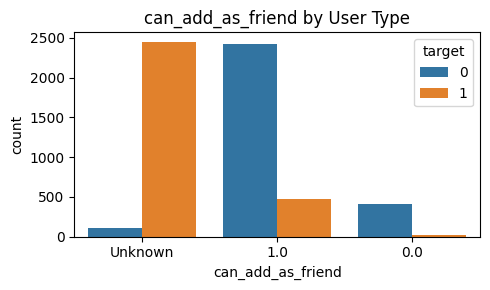

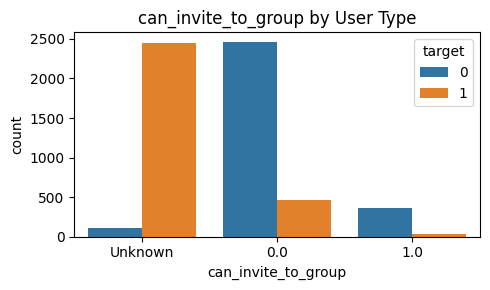

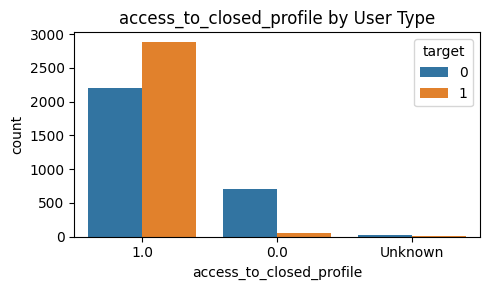

In [18]:
settings_cols = [
    'can_post_on_wall', 'can_send_message', 'can_add_as_friend',
    'can_invite_to_group', 'access_to_closed_profile'
]

for col in settings_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(data=df, x=col, hue='target')
    plt.title(f"{col} by User Type")
    plt.tight_layout()
    plt.show()


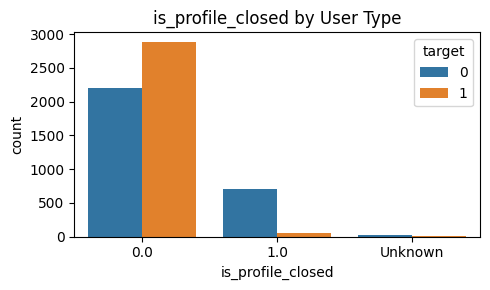

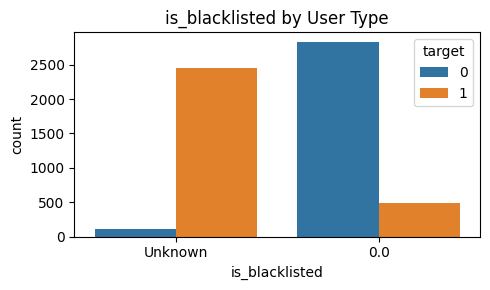

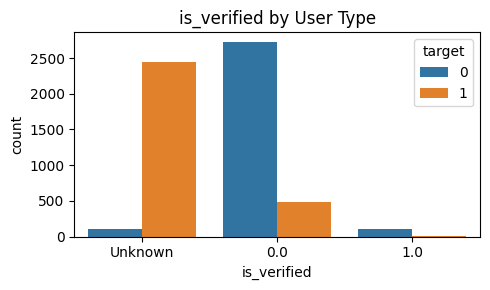

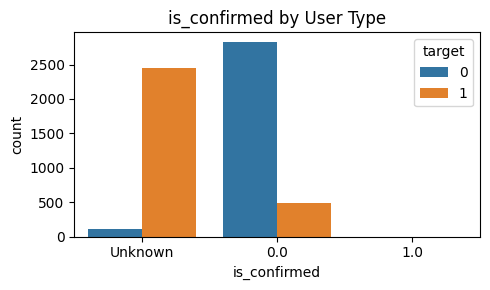

In [19]:
privacy_cols = ['is_profile_closed', 'is_blacklisted', 'is_verified', 'is_confirmed']

for col in privacy_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(data=df, x=col, hue='target')
    plt.title(f"{col} by User Type")
    plt.tight_layout()
    plt.show()


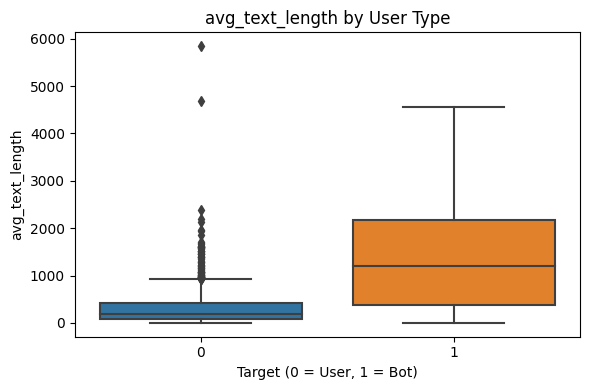

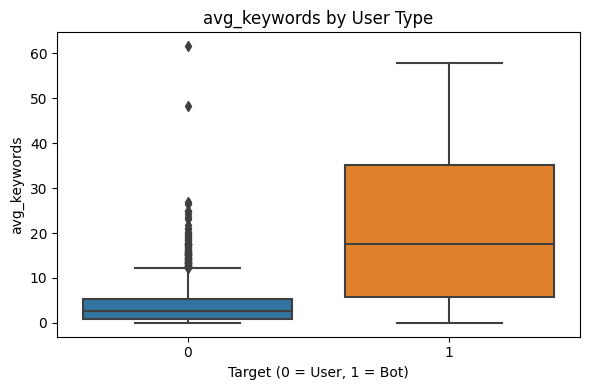

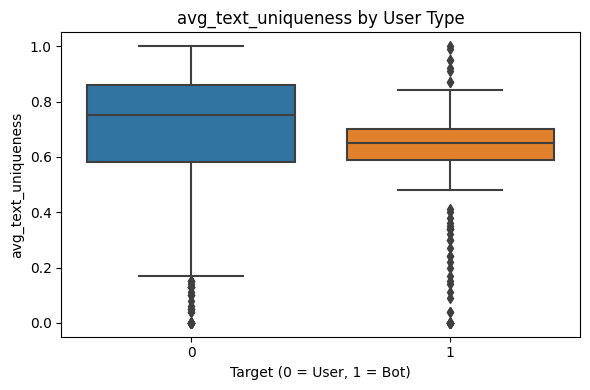

In [20]:
text_cols = ['avg_text_length', 'avg_keywords', 'avg_text_uniqueness']

for col in text_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='target', y=col)
    plt.title(f"{col} by User Type")
    plt.xlabel("Target (0 = User, 1 = Bot)")
    plt.tight_layout()
    plt.show()


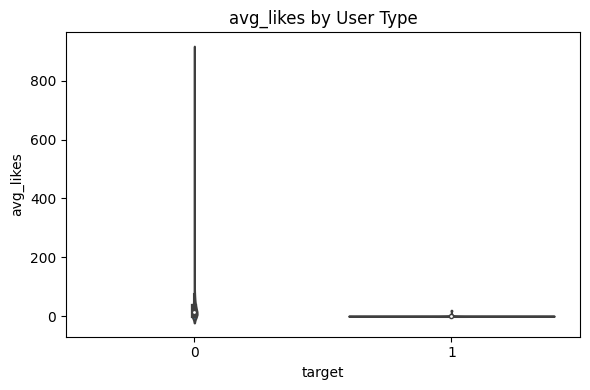

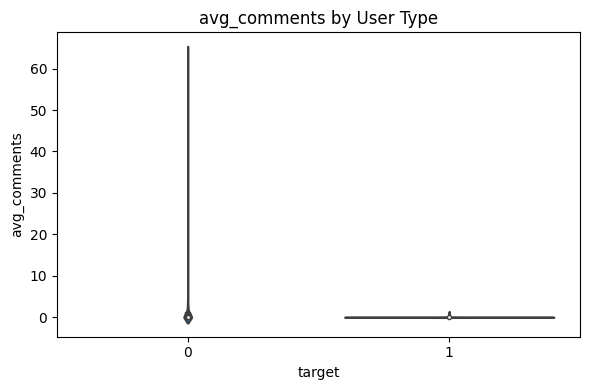

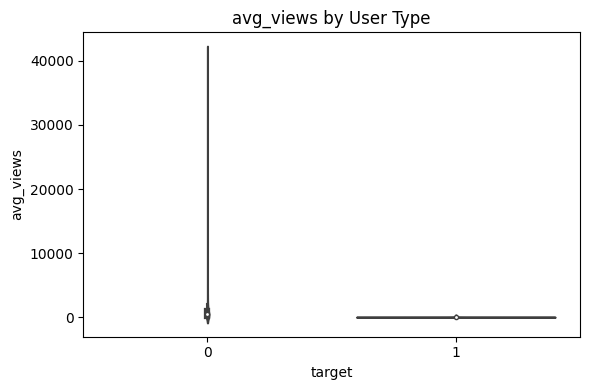

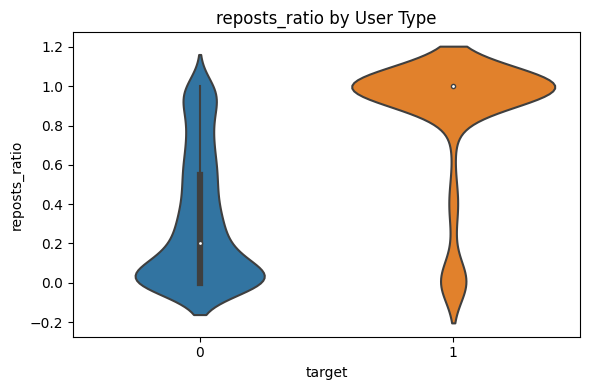

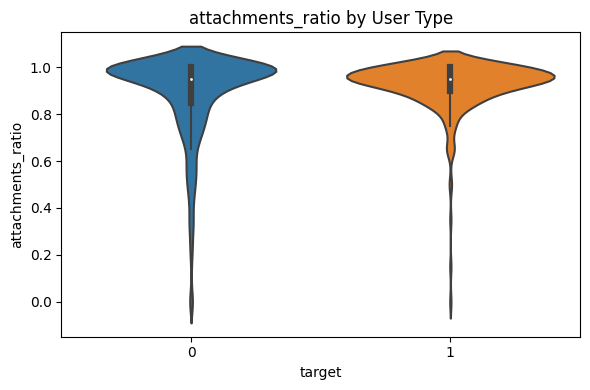

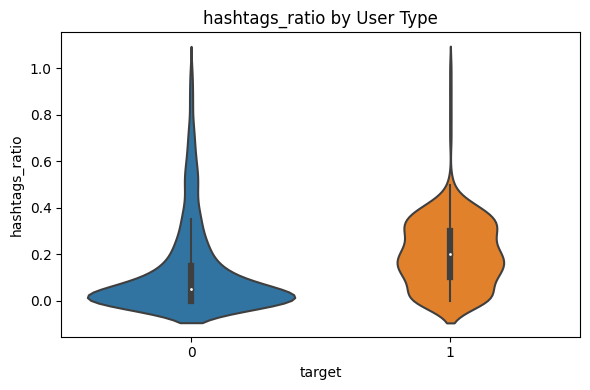

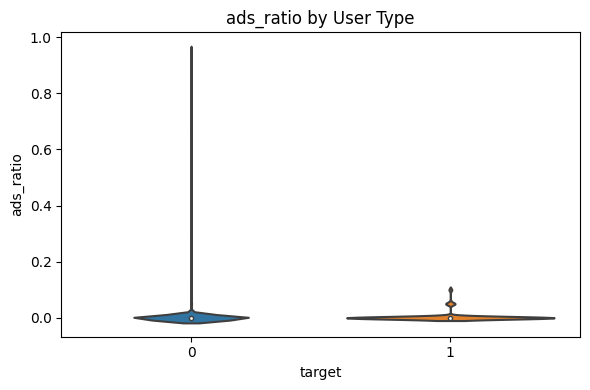

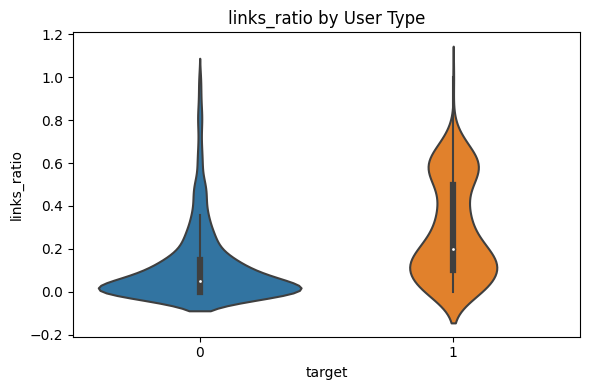

In [21]:
interaction_cols = [
    'avg_likes', 'avg_comments', 'avg_views',
    'reposts_ratio', 'attachments_ratio', 'hashtags_ratio',
    'ads_ratio', 'links_ratio'
]

for col in interaction_cols:
    plt.figure(figsize=(6, 4))
    sns.violinplot(data=df, x='target', y=col)
    plt.title(f"{col} by User Type")
    plt.tight_layout()
    plt.show()


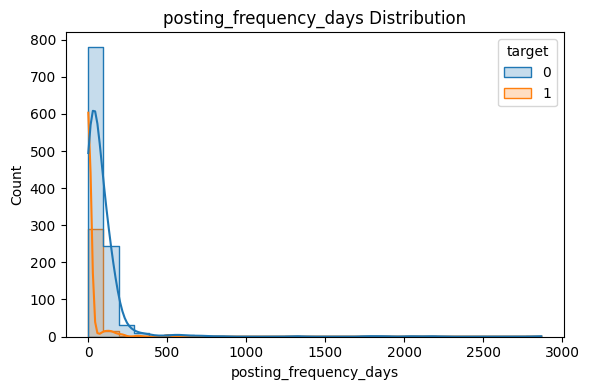

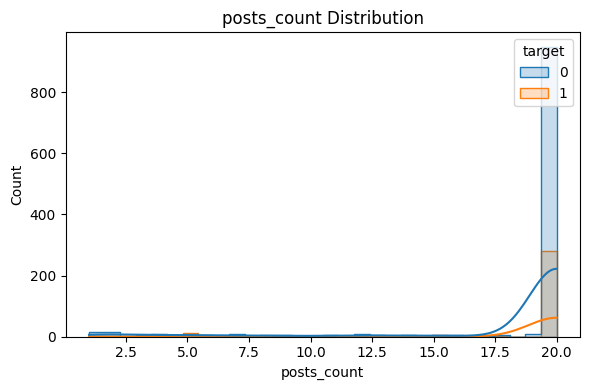

In [22]:
posting_cols = ['posting_frequency_days', 'posts_count']

for col in posting_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, hue='target', kde=True, element='step', bins=30)
    plt.title(f"{col} Distribution")
    plt.tight_layout()
    plt.show()


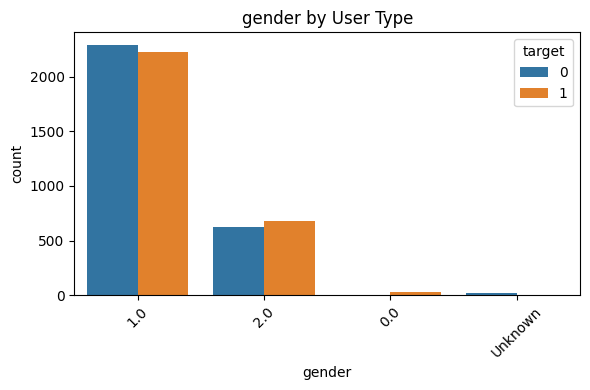

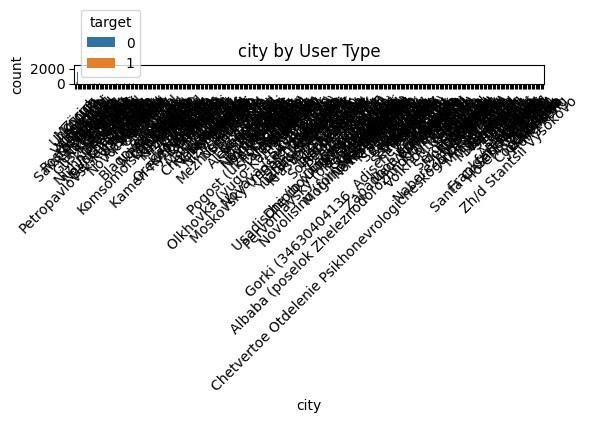

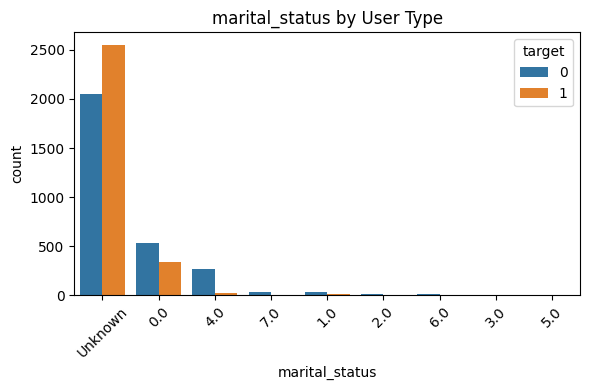

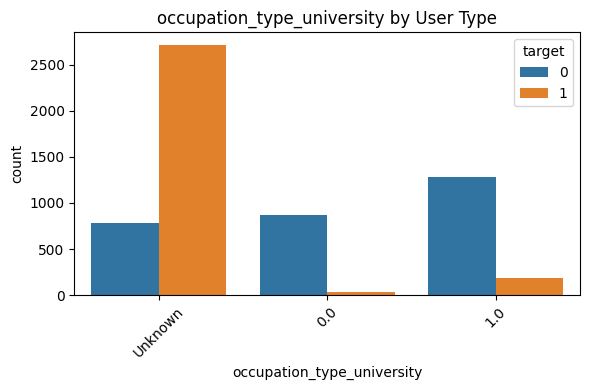

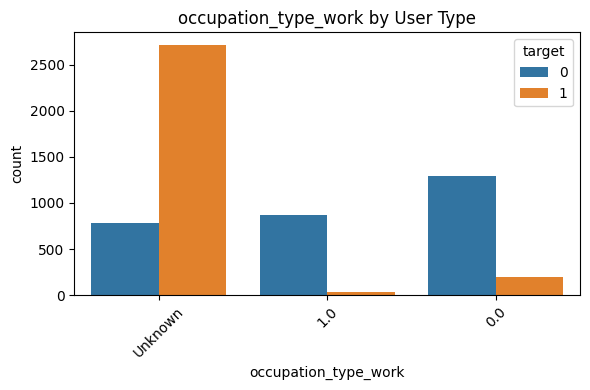

In [23]:
demographic_cols = ['gender', 'city', 'marital_status', 'occupation_type_university', 'occupation_type_work']

for col in demographic_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue='target')
    plt.title(f"{col} by User Type")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


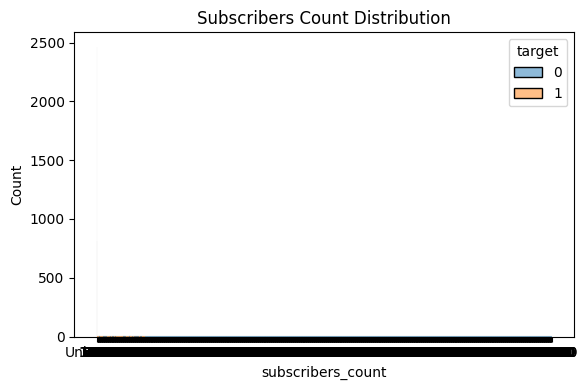

In [24]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='subscribers_count', hue='target', bins=40)
plt.title("Subscribers Count Distribution")
plt.tight_layout()
plt.show()


## Predictive modeling

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [26]:
# Step 1: Handle missing values
df.fillna("Unknown", inplace=True)

In [27]:
# Step 2: Convert categorical columns using Label Encoding
categorical_cols = df.select_dtypes(include=['object']).columns
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))


In [28]:
# Step 3: Define Features and Target
X = df.drop(columns=['target'])  # Features
y = df['target']

In [29]:
# Step 4: Train-Test Splitting (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
# Step 5: Initialize Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

In [31]:
# Step 6: Train & Evaluate Models
results = {}

In [32]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred) * 100
    results[name] = accuracy
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

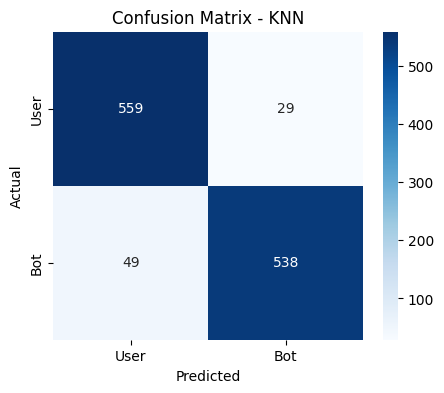

Logistic Regression: 93.45% Accuracy
Random Forest: 96.60% Accuracy
SVM: 81.28% Accuracy
Naive Bayes: 89.36% Accuracy
Decision Tree: 95.49% Accuracy
KNN: 93.36% Accuracy


In [33]:
# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['User', 'Bot'], yticklabels=['User', 'Bot'])
plt.title(f'Confusion Matrix - {name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Step 7: Display Accuracy Results
for model, acc in results.items():
    print(f"{model}: {acc:.2f}% Accuracy")

## thank you...pls upvote!!!!